In [1]:
from collections import defaultdict
from itertools import zip_longest
import json

from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from text2cypher.architecture.agents import RetrievalAgent

all_tools = list(RetrievalAgent.ToolKit().tools.keys())


/home/nico/python-projects/text-to-cypher/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Loading Data

In [6]:
df = pd.read_csv("../data/interim/evaluations/gpt-4.1-old/test.csv")
predictions_df = pd.read_csv("../data/interim/neo4j-2024v1/gpt-4.1/test-trajectories.csv")
df = df.merge(
    predictions_df, on="df.index"
)
df['exact_match'] = (df['jaccard_similarity'] == 1.0).apply(int)
df

,df.index,jaccard_similarity,psj_similarity,is_executable,is_empty,json_trajectory,generated_cypher,exact_match
0,0.0,1.000000,1.0,True,False,"[{""role"": ""system"", ""content"": ""## ROLE AND TA...",MATCH (s:Supplier)-[:SUPPLIES]->(p:Product)\nW...,1
1,4.0,0.000000,1.0,True,False,"[{""role"": ""system"", ""content"": ""## ROLE AND TA...",MATCH (a:Article)-[:MENTIONS]->(o:Organization...,0
2,11.0,0.333333,1.0,True,False,"[{""role"": ""system"", ""content"": ""## ROLE AND TA...",MATCH (m:Movie)-[:IN_GENRE]->(g:Genre) WHERE m...,0
3,12.0,1.000000,1.0,True,False,"[{""role"": ""system"", ""content"": ""## ROLE AND TA...","MATCH (u:User)-[:VIP]->(s:Stream) WITH u, coun...",1
4,13.0,1.000000,1.0,True,False,"[{""role"": ""system"", ""content"": ""## ROLE AND TA...",MATCH (t:Tweet) RETURN t.id AS tweetId ORDER B...,1
...,...,...,...,...,...,...,...,...
2466,4683.0,NaN,NaN,NaN,NaN,"[{""role"": ""system"", ""content"": ""## ROLE AND TA...",NaN,0
2467,4699.0,NaN,NaN,NaN,NaN,"[{""role"": ""system"", ""content"": ""## ROLE AND TA...",NaN,0
2468,4776.0,NaN,NaN,NaN,NaN,"[{""role"": ""system"", ""content"": ""## ROLE AND TA...",NaN,0
2469,4807.0,NaN,NaN,NaN,NaN,"[{""role"": ""system"", ""content"": ""## ROLE AND TA...",NaN,0


# Effectiveness Evaluation

In [317]:
# fill NaN values in "jaccard_similarity" and "psj_similarity" with 0
na_to_0_df = df.fillna({"jaccard_similarity": 0, "psj_similarity": 0})
na_to_0_df['exact_match'] = (na_to_0_df['jaccard_similarity'] == 1.0).apply(int)
print(f"Jaccard:\t{na_to_0_df['jaccard_similarity'].mean():.4f} ± {na_to_0_df['jaccard_similarity'].std():.4f}")
print(f"Exact Match:\t{na_to_0_df['exact_match'].mean():.4f} ± {na_to_0_df['exact_match'].std():.4f}")
print(f"PSJ:\t\t{na_to_0_df['psj_similarity'].mean():.4f} ± {na_to_0_df['psj_similarity'].std():.4f}")

Jaccard:	0.4122 ± 0.4485
Exact Match:	0.3262 ± 0.4689
PSJ:		0.6937 ± 0.4330


In [318]:
# create a mask for rows having NaN in jaccard_similarity or psj_similarity
nan_mask = df["jaccard_similarity"].isna() | df["psj_similarity"].isna()
no_na_df = df[~nan_mask].copy()

In [319]:
print(f"Jaccard:\t{no_na_df['jaccard_similarity'].mean():.4f} ± {no_na_df['jaccard_similarity'].std():.4f}")
print(f"Exact Match:\t{no_na_df['exact_match'].mean():.4f} ± {no_na_df['exact_match'].std():.4f}")
print(f"PSJ:\t\t{no_na_df['psj_similarity'].mean():.4f} ± {no_na_df['psj_similarity'].std():.4f}")

Jaccard:	0.4626 ± 0.4499
Exact Match:	0.3660 ± 0.4818
PSJ:		0.7785 ± 0.3800


In [320]:
non_empty_df = no_na_df[(no_na_df["is_empty"] == False)]
print(f"Jaccard:\t{non_empty_df['jaccard_similarity'].mean():.4f} ± {non_empty_df['jaccard_similarity'].std():.4f}")
print(f"Exact Match:\t{non_empty_df['exact_match'].mean():.4f} ± {non_empty_df['exact_match'].std():.4f}")
print(f"PSJ:\t\t{non_empty_df['psj_similarity'].mean():.4f} ± {non_empty_df['psj_similarity'].std():.4f}")

Jaccard:	0.4850 ± 0.4477
Exact Match:	0.3819 ± 0.4860
PSJ:		0.8220 ± 0.3410


# Efficiency Evaluation

In [321]:
def plot_lines(ax: Axes, mean_parallel_calls: list[float], std_parallel_calls: list[float]):
    # Convert to numpy arrays for easier manipulation
    mean_array = np.array(mean_parallel_calls)
    std_array = np.array(std_parallel_calls)
    steps = np.arange(len(mean_array)) + 1

    # Plot mean line
    ax.plot(steps, mean_array, 'b-', linewidth=1.5, label='Mean parallel tool calls')

    # Add shaded region for std
    ax.fill_between(
        steps, 
        mean_array - std_array, 
        mean_array + std_array, 
        alpha=0.3, 
        color='blue', 
        label='± 1 std'
    )

def plot_boxplot(ax: Axes, padded_trajectories: np.ndarray):
    # Prepare data for boxplot (each column is a time step)
    # Filter out NaN values for each time step
    boxplot_data = []
    steps = []
    for i in range(padded_trajectories.shape[1]):
        step_data = padded_trajectories[:, i]
        # Remove NaN values for this step
        valid_data = step_data[~np.isnan(step_data)]
        if len(valid_data) > 0:
            boxplot_data.append(valid_data)
            steps.append(i + 1)

    # Create boxplot
    bp = ax.boxplot(
        boxplot_data, positions=steps, widths=0.6, patch_artist=True,
        boxprops=dict(facecolor='lightblue', alpha=0.7),
        medianprops=dict(color='red', linewidth=1.5),
        whiskerprops=dict(color='blue', linewidth=1),
        capprops=dict(color='blue', linewidth=1)
    )

def plot_full_lines(ax: Axes, mean_parallel_calls: list[float], std_parallel_calls: list[float]):
    plot_lines(ax, mean_parallel_calls, std_parallel_calls)
    
    # Add grid and labels
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Assistant Turn Number') # , fontsize=12
    ax.set_ylabel('Number of Parallel Tool Calls') # , fontsize=12
    ax.set_title('Parallel Tool Calls Over Chat Session Progress', fontweight='bold') # , fontsize=14
    ax.legend(loc='best')

    # Set y-axis to start from 0
    ax.set_ylim(bottom=0)

def plot_full_boxplot(ax: Axes, padded_trajectories: np.ndarray):
    plot_boxplot(ax, padded_trajectories)
    
    # Add grid and labels
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xlabel('Assistant Turn Number')
    ax.set_ylabel('Number of Parallel Tool Calls')
    ax.set_title('Parallel Tool Calls Distribution Over Chat Session Progress', fontweight='bold')

    # Set y-axis to start from 0
    ax.set_ylim(bottom=0)

def plot_tool_distribution_by_turn_with_hist(distribution_df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(8, 4))
    
    all_tools = distribution_df.columns.tolist()
    turns = distribution_df.index.tolist()
    
    # Use seaborn color palette for better aesthetics
    colors = sns.color_palette("hls", len(all_tools))
    
    # Create stacked bar chart with seaborn styling
    sns.set_style("whitegrid")
    bottom = np.zeros(len(turns))
    
    for i, tool in enumerate(all_tools):
        percentages = distribution_df[tool].values
        ax.bar(
            turns, percentages, bottom=bottom, label=tool, 
            color=colors[i], edgecolor='white', linewidth=0.5
        )
        bottom += percentages
    
    # Styling improvements
    ax.set_xlabel('Assistant Turn Number', fontsize=16)
    ax.set_ylabel('Percentage of Tool Calls (%)', fontsize=16)
    # ax.set_title(
    #     'Distribution of Tools Called at Each Assistant Turn', 
    #     fontweight='bold', fontsize=14, pad=20
    # )
    
    # Improve legend
    # ax.legend(
    #     loc='upper left', bbox_to_anchor=(1.02, 1), 
    #     frameon=True, shadow=True, ncol=1
    # )
    
    # Set grid style
    ax.grid(True, alpha=0.3, axis='y', linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)
    
    # Set limits and ticks
    ax.set_ylim(0, 100)
    ax.set_xlim(turns[0] - 0.5, turns[-1] + 0.5)
    
    # Add percentage on y-axis
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
    
    # Remove top and right spines for cleaner look
    # sns.despine(ax=ax)
    
    plt.tight_layout()
    plt.show()
    
    # Reset style to default after plotting
    sns.reset_defaults()

def plot_tool_distribution_by_turn_with_heatmap(distribution_df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(12, 6))

    # Use seaborn heatmap to visualize the distribution
    sns.heatmap(
        distribution_df.T,  # Transpose to have tools on y-axis
        ax=ax,
        cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True),
        cbar_kws={'label': 'Percentage of Tool Calls (%)'},
        annot=True,
        fmt=".1f"
    )
    ax.set_xlabel('Assistant Turn Number')
    ax.set_ylabel('Tool Name')
    ax.set_title('Heatmap of Tool Call Distribution by Assistant Turn', fontweight='bold')
    plt.tight_layout()
    plt.show()


In [322]:
def create_distribution_df(tool_calls_by_turn: dict[int, dict[str, int]], max_turn: int, all_tools: list[str], normalize: bool = True) -> pd.DataFrame:
    turn_numbers = list(range(1, max_turn + 1))

    if normalize:
        tool_percentages_by_turn = {}
        for turn, tool_calls_distr in tool_calls_by_turn.items():
            total = sum(tool_calls_distr.values())
            tool_percentages_by_turn[turn] = {
                tool: (count / total * 100)
                for tool, count in tool_calls_distr.items()
            }
    else:
        tool_percentages_by_turn = tool_calls_by_turn

    # Create a dictionary to hold percentage data for each tool
    tool_data = {tool: [] for tool in all_tools}
    for turn in turn_numbers:
        turn_tools = tool_percentages_by_turn.get(turn, {})
        for tool in all_tools:
            # Append percentage if tool was used in this turn, otherwise 0
            tool_data[tool].append(turn_tools.get(tool, 0))

    # Create DataFrame
    tool_distribution_df = pd.DataFrame(tool_data, index=turn_numbers)
    tool_distribution_df.index.name = 'Turn'
    return tool_distribution_df

def get_chat_stats(
    messages: list[dict],
    stats: dict[str, list[int]],
    tool_calls_by_turn: dict[int, dict[str, int]], 
    errors_by_turn: dict[int, dict[str, int]],
    parallel_calls_by_tool: dict[str, list[int]],
    all_tools: list[str],
    batch_tools: dict[str, str] = None,
) -> dict:
    
    turn_number = 0
    for message in messages:
        msg_role = message["role"]
        
        if msg_role == "assistant":
            turn_number += 1
            tool_calls = message.get("tool_calls", [])

            if tool_calls:
                stats['parallel_calls'].append(len(tool_calls))

            last_tool_calls = []
            called_tools = set()
            for call_str in tool_calls:
                call_dict = json.loads(call_str)
                fn = call_dict["function"]
                fn_name = fn['name']
                tool_id = call_dict.get("id", "")
                last_tool_calls.append((fn_name, tool_id))

                tool_calls_by_turn[turn_number][fn_name] += 1
                if fn_name not in called_tools:
                    parallel_calls_by_tool[fn_name].append(1)
                    called_tools.add(fn_name)
                else:
                    parallel_calls_by_tool[fn_name][-1] += 1
                # stats["total_calls_by_turn"][turn_number] += 1
                
                # Track batch sizes for batching-compatible tools
                if fn_name in batch_tools:
                    batch_param = batch_tools[fn_name]
                    args = fn['arguments']
                    if batch_param in args and isinstance(args[batch_param], list):
                        batch_size = len(args[batch_param])
                        # stats["all_tools"].append(batch_size)
                        # stats[fn_name].append(batch_size)
                        parallel_calls_by_tool[fn_name][-1] += batch_size - 1 # Adjust parallel calls for batched calls
                        stats['parallel_calls'][-1] += batch_size - 1  # Adjust parallel calls for batched calls
                    
        elif msg_role == "tool":
            # Check if this tool call resulted in an error
            if "[ERROR]" in message["content"]:
                tool_call_id = message.get("tool_call_id", "")
                
                # Find which tool this error belongs to
                tool_name = None
                for fn_name, tid in last_tool_calls:
                    if tid == tool_call_id or tool_call_id == "":
                        tool_name = fn_name
                        break
                
                if tool_name:
                    errors_by_turn[turn_number][tool_name] += 1
                else:
                    # If we can't identify the tool, mark as "unknown"
                    errors_by_turn[turn_number]["unknown"] += 1
            else:
                errors_by_turn[turn_number]["no_error"] += 1


In [323]:
stats = {
    "parallel_calls": [],
}
all_trajectories = []
tool_calls_by_turn = defaultdict(lambda: defaultdict(int))
errors_by_turn = defaultdict(lambda: defaultdict(int))
turn_parallel_calls_by_tool = {
    tool_name: [] for tool_name in all_tools
}

na_df = df[nan_mask]
# compute batch stats for each row
for index, row in no_na_df.iterrows():
    messages = json.loads(row["json_trajectory"])
    parallel_calls_before = len(stats["parallel_calls"])
    get_chat_stats(messages, stats, tool_calls_by_turn, errors_by_turn, turn_parallel_calls_by_tool,
        all_tools,
        batch_tools = {
            "get_properties_from": "of_types",
            "get_domains_ranges_of": "relationships",
            "get_components_with_property": "keys",
        }            
    )
    
    # Extract parallel calls for this trajectory
    parallel_calls = stats["parallel_calls"][parallel_calls_before:]
    if parallel_calls:  # Only include trajectories with tool calls
        all_trajectories.append(parallel_calls)


## Batching Capabilities

In [324]:
# Create a well-formatted table with statistics
results = []
for key, sizes in turn_parallel_calls_by_tool.items():
    if sizes:
        results.append({
            "Metric": key,
            "Mean": np.mean(sizes),
            "Std": np.std(sizes),
            "Mode": int(pd.Series(sizes).mode()[0]),
            "Min": np.min(sizes),
            "Median": np.median(sizes),
            "Max": np.max(sizes),
            "Count": len(sizes)
        })
    else:
        results.append({
            "Metric": key,
            "Mean": 0,
            "Std": 0,
            "Mode": 0,
            "Min": 0,
            "Median": 0,
            "Max": 0,
            "Count": 0
        })


In [325]:
batch_stats_df = pd.DataFrame(results)
print("Batch Size Statistics:")
print(batch_stats_df.to_string(index=False, float_format=lambda x: f'{x:.2f}'))

Batch Size Statistics:
                      Metric  Mean  Std  Mode  Min  Median  Max  Count
        execute_cypher_query  1.01 0.11     1    1    1.00    4   2928
                  search_for  3.72 1.36     4    1    4.00   11   2280
         get_properties_from  1.44 0.73     1    1    1.00    6   3080
       get_domains_ranges_of  1.46 0.86     1    0    1.00   12   1593
get_components_with_property  2.10 1.47     1    1    2.00    9    393
   register_retrieval_result  1.00 0.00     1    1    1.00    1   4448


## Parallel Tool Calls Over Time

In [326]:
# Pad all trajectories to the same length with NaN
max_length = max(len(t) for t in all_trajectories)
padded_trajectories = np.array(
    list(zip_longest(*all_trajectories, fillvalue=np.nan))
).T  # Shape: (n_trajectories, max_length)

# Calculate mean and std along axis 0 (across trajectories), ignoring NaNs
mean_parallel_calls = np.nanmean(padded_trajectories, axis=0)
std_parallel_calls = np.nanstd(padded_trajectories, axis=0)

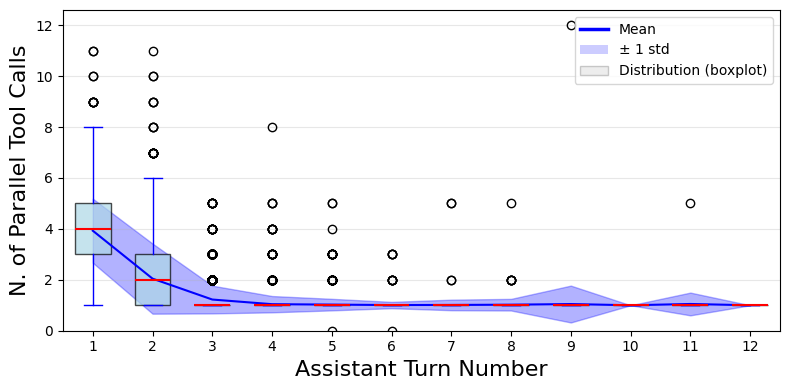

In [327]:
# Create overlaid plot with both boxplot and line
fig, ax = plt.subplots(figsize=(8, 4))

plot_boxplot(ax, padded_trajectories)
plot_lines(ax, mean_parallel_calls, std_parallel_calls)

# Add grid and labels
ax.grid(True, alpha=0.3, axis='y', zorder=0)
ax.set_xlabel('Assistant Turn Number', fontsize=16)
ax.set_ylabel('N. of Parallel Tool Calls', fontsize=16)
# ax.set_title('Parallel Tool Calls Over Chat Session Progress (Combined View)', fontweight='bold')

# Create custom legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='b', linewidth=2.5, label='Mean'),
    Patch(facecolor='blue', alpha=0.2, label='± 1 std'),
    Patch(facecolor='lightgray', alpha=0.4, edgecolor='gray', label='Distribution (boxplot)')
]
ax.legend(handles=legend_elements, loc='best')

ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

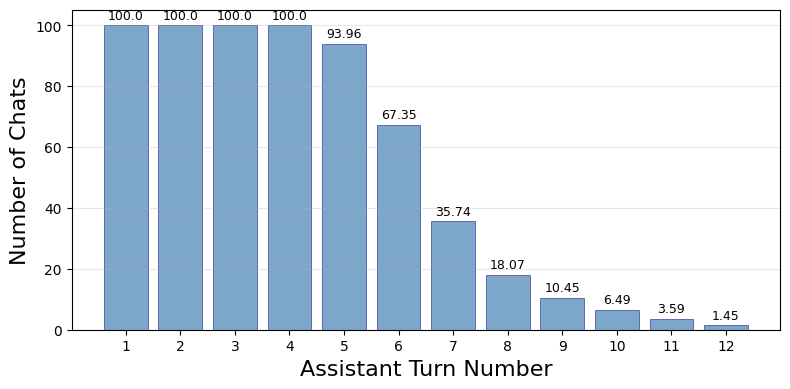

In [328]:
# Create histogram of how many chats reach each assistant turn number
fig, ax = plt.subplots(figsize=(8, 4))

# Calculate how many trajectories reach at least each turn number
max_turns = max(len(t) for t in all_trajectories)
turn_numbers = np.arange(1, max_turns + 1)
trajectories_reaching = []

total_trajectories = len(all_trajectories)
for turn in turn_numbers:
    count = sum(1 for trajectory in all_trajectories if len(trajectory) >= turn)
    trajectories_reaching.append(round(count / total_trajectories * 100, 2))

# Create bar plot
bars = ax.bar(turn_numbers, trajectories_reaching, color='steelblue', alpha=0.7, edgecolor='navy', linewidth=0.5)

# Add grid and labels
ax.grid(True, alpha=0.3, axis='y', zorder=0)
ax.set_xlabel('Assistant Turn Number', fontsize=16)
ax.set_ylabel('Number of Chats', fontsize=16)
# ax.set_title('Number of Chats Reaching Each Assistant Turn', fontweight='bold')

# Add value labels on top of bars for better readability (optional, only for smaller datasets)
if max_turns <= 15:
    for i, (turn, count) in enumerate(zip(turn_numbers, trajectories_reaching)):
        ax.text(turn, count + max(trajectories_reaching) * 0.01, str(count), 
                ha='center', va='bottom', fontsize=9)

# Set x-axis to show integer ticks
ax.set_xticks(turn_numbers)

plt.tight_layout()
plt.show()

## Tool Calls Distribution Over Time

In [329]:
max_turn = df['json_trajectory'].apply(
    lambda jt: len(list(filter(lambda x: x['role'] == 'assistant', json.loads(jt))))
).max()
print(f"Max turns across all chats: {max_turn}")

Max turns across all chats: 13


In [330]:
distribution_df = create_distribution_df(tool_calls_by_turn, max_turn, all_tools, normalize=True)

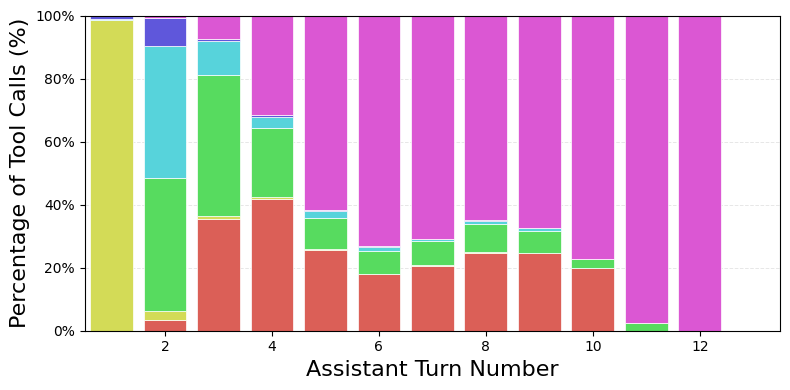

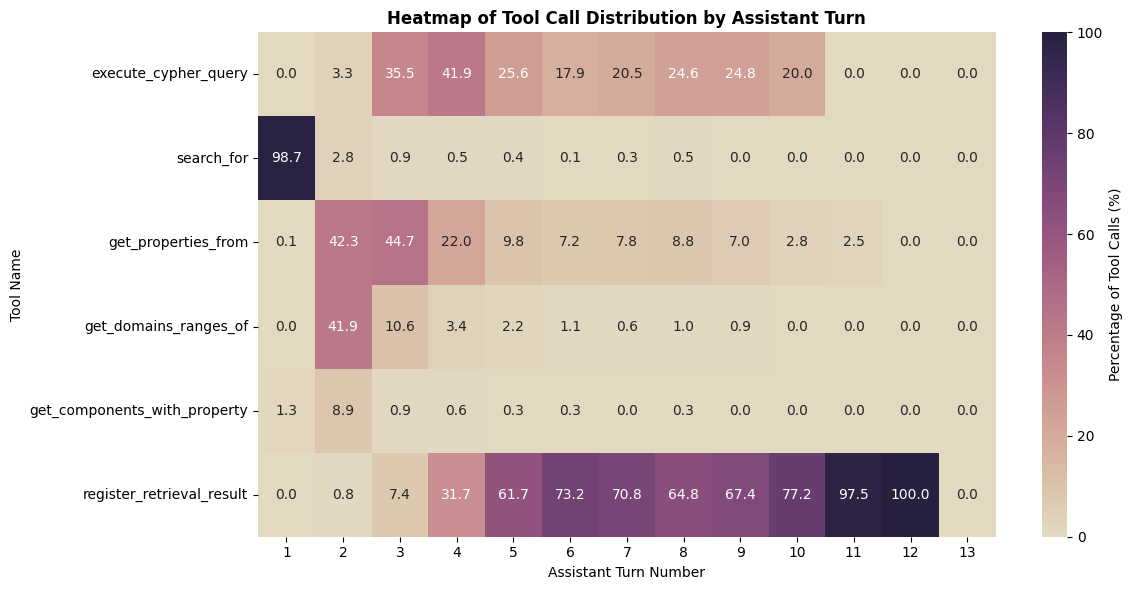

In [331]:
plot_tool_distribution_by_turn_with_hist(distribution_df)
plot_tool_distribution_by_turn_with_heatmap(distribution_df)


## Errors Distribution Over Time

In [332]:
distribution_df = create_distribution_df(errors_by_turn, max_turn, all_tools, normalize=True)

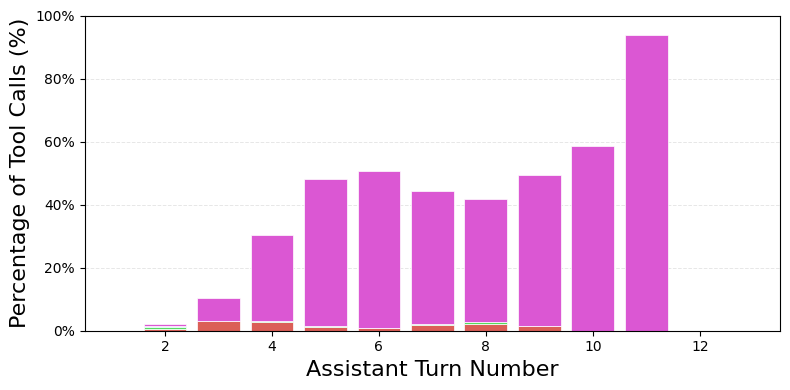

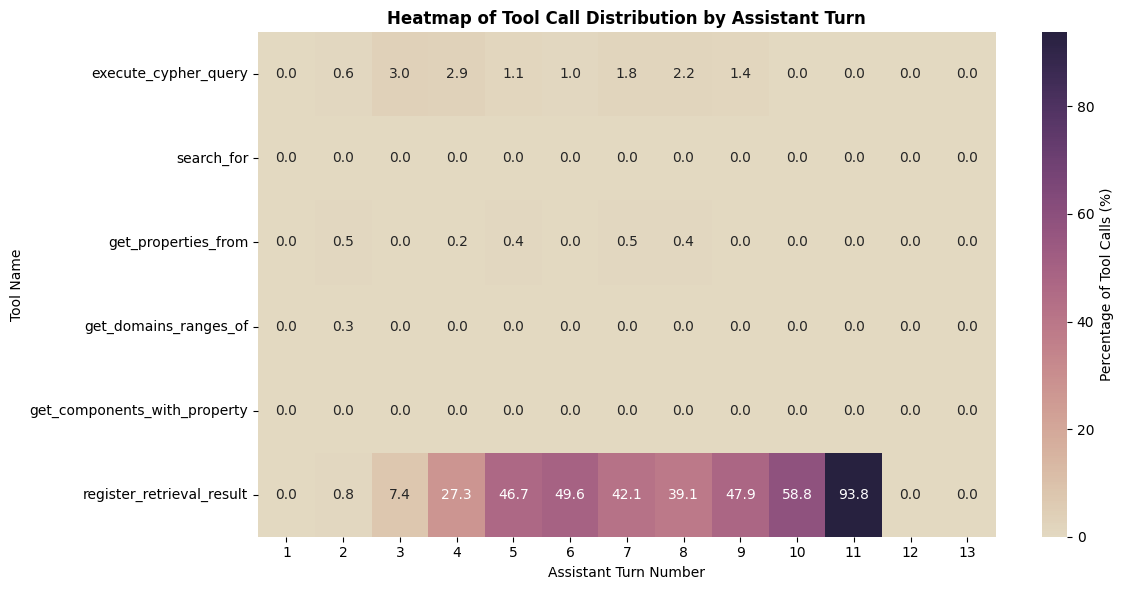

In [333]:
plot_tool_distribution_by_turn_with_hist(distribution_df)
plot_tool_distribution_by_turn_with_heatmap(distribution_df)